In [1]:
# %%
"""
Integrated Landslide Detection Pipeline
This notebook covers data preparation, exploratory analysis, composite image creation,
model training with cross-validation, evaluation, and submission generation.
Unique naming to avoid duplication in evaluation environments.
"""
# %%
# Imports and Setup
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import torch
import gc
#import albumentations as A
import albumentations as albu  # Changed alias from A to albu
from fastai.vision.all import *
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import timm


In [2]:
# %%
# 1. Configuration and Reproducibility
class PipelineConfig:
    """Configuration parameters for the pipeline"""
    RANDOM_STATE = 42
    #DRIVE_MOUNT_POINT = '/content/drive'
    BASE_DIR = '/kaggle/input/slideandseekclasificationlandslidedetectiondataset'
    TRAIN_CSV = BASE_DIR + '/Train.csv'
    TEST_CSV = BASE_DIR + '/Test.csv'
    RAW_TRAIN_DATA = BASE_DIR + '/train_data/train_data'
    RAW_TEST_DATA = BASE_DIR + '/test_data/test_data'
    OUTPUT_DIR = '/kaggle/working/processed_images'
    COMPOSITE_SCHEMES = [
        ['red', 'green', 'blue'],
        ['nir', 'red', 'green']
    ]
    BAND_LABELS = [
        'red', 'green', 'blue', 'nir',
        'desc_vv', 'desc_vh', 'desc_diff_vv', 'desc_diff_vh',
        'asc_vv', 'asc_vh', 'asc_diff_vv', 'asc_diff_vh'
    ]
    IMAGE_SIZE = 224
    N_SPLITS = 5
    BATCH_SIZE = 16
    EPOCHS = 12
    MODEL_NAME = "beitv2_large_patch16_224.in1k_ft_in22k_in1k" #'beitv2_base_patch16_224'#"beitv2_large_patch16_224.in1k_ft_in22k_in1k"
    TTA_ROUNDS = 5
    NUM_CLASSES = 2

# Seed setting for reproducibility
def set_seed(seed: int, cuda: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if cuda and torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(PipelineConfig.RANDOM_STATE)
# %%
# # 2. Mount Google Drive
# from google.colab import drive
# _drive = drive.mount(PipelineConfig.DRIVE_MOUNT_POINT, force_remount=True)
# %%
# 3. Load Metadata
train_df = pd.read_csv(PipelineConfig.TRAIN_CSV)
test_df = pd.read_csv(PipelineConfig.TEST_CSV)
# Add paths for numpy arrays
train_df['npy_path'] = train_df['ID'].map(
    lambda x: f"{PipelineConfig.RAW_TRAIN_DATA}/{x}.npy"
)
test_df['npy_path'] = test_df['ID'].map(
    lambda x: f"{PipelineConfig.RAW_TEST_DATA}/{x}.npy"
)

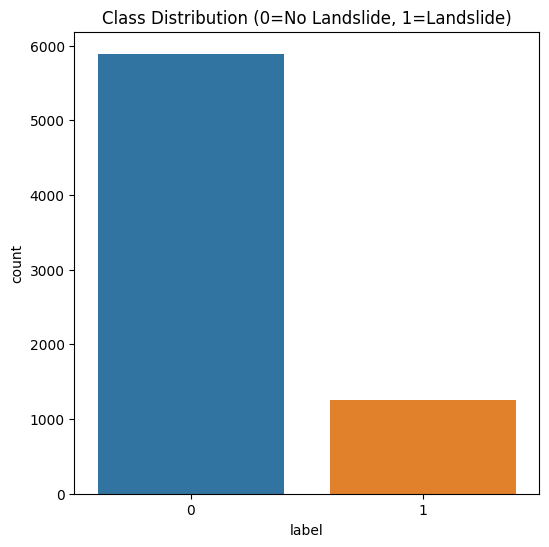

In [3]:

# %%
# 4. Exploratory Data Analysis (EDA)
plt.figure(figsize=(6,6))
sns.countplot(x='label', data=train_df)
plt.title('Class Distribution (0=No Landslide, 1=Landslide)')
plt.show()




Label distribution:
 label
0    0.824402
1    0.175598
Name: proportion, dtype: float64


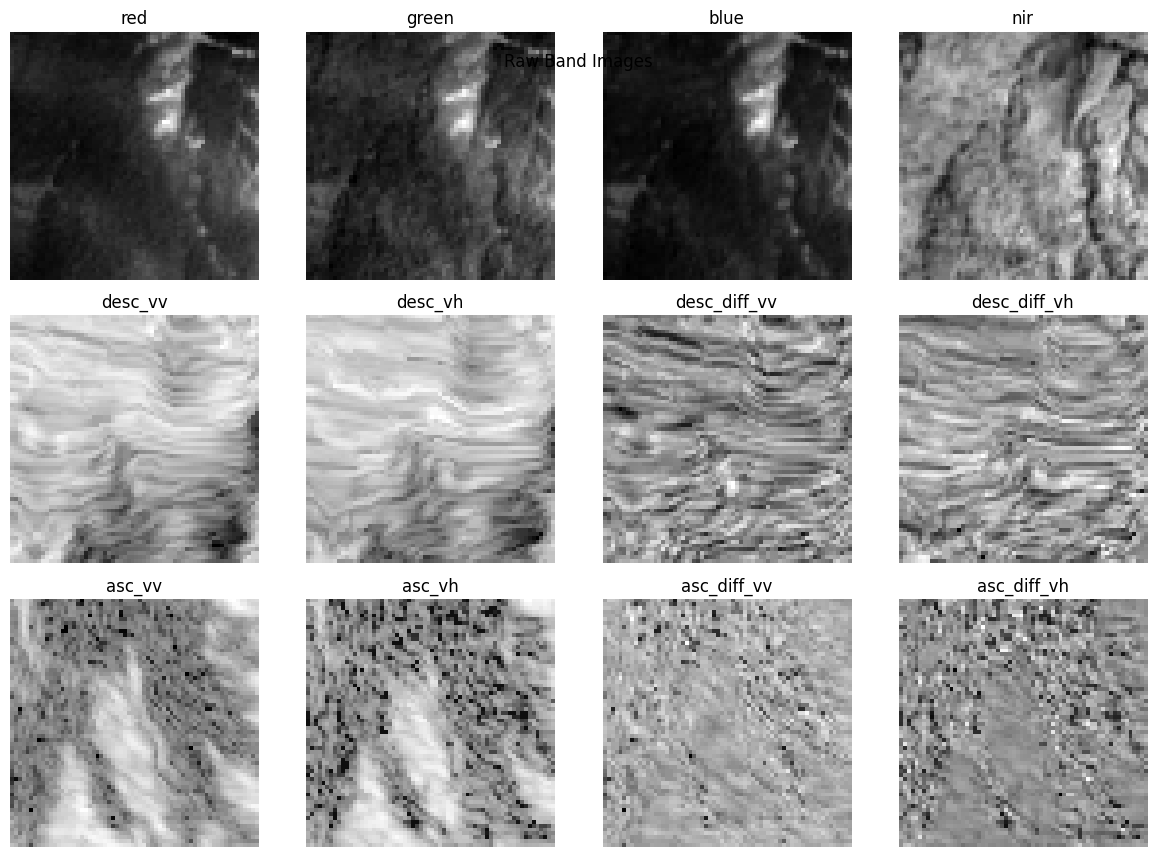

In [4]:
print("Label distribution:\n", train_df['label'].value_counts(normalize=True))
# %%
# Visualize one sample's bands
sample = np.load(train_df.loc[0, 'npy_path'])
fig, axes = plt.subplots(3,4, figsize=(12,9))
for idx, band in enumerate(PipelineConfig.BAND_LABELS):
    ax = axes[idx//4, idx%4]
    ax.imshow(sample[:,:,idx], cmap='gray')
    ax.set_title(band)
    ax.axis('off')
plt.suptitle('Raw Band Images', y=0.9)
plt.tight_layout()
plt.show()
# %%

In [5]:
# 5. Composite Image Creation Function

def build_and_store_composites(metadata: pd.DataFrame,
                               schemes: list,
                               save_root: str,
                               subset_tag: str):
    """
    Create composite RGB images from selected bands and save to disk.
    """
    for scheme in schemes:
        folder = Path(save_root) / subset_tag / '_'.join(scheme)
        folder.mkdir(parents=True, exist_ok=True)

    for _, row in tqdm(metadata.iterrows(), total=len(metadata)):
        tile = np.load(row['npy_path'])
        for scheme in schemes:
            idxs = [PipelineConfig.BAND_LABELS.index(b) for b in scheme]
            img = tile[:,:,idxs]
            # normalize
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            img = (img * 255).astype(np.uint8)
            im_pil = Image.fromarray(img)
            save_path = Path(save_root) / subset_tag / '_'.join(scheme) / f"{row['ID']}.png"
            im_pil.save(save_path)

# %%
# Generate composites for train and test
dirs = PipelineConfig.OUTPUT_DIR
build_and_store_composites(train_df, PipelineConfig.COMPOSITE_SCHEMES, dirs, 'train')
build_and_store_composites(test_df, PipelineConfig.COMPOSITE_SCHEMES, dirs, 'test')

# Update dataframe with new image paths
train_df['img_path'] = train_df['ID'].map(
    lambda x: f"{dirs}/train/{'_'.join(PipelineConfig.COMPOSITE_SCHEMES[1])}/{x}.png"
)
# use second scheme (e.g. nir_red_green)
test_df['img_path'] = test_df['ID'].map(
    lambda x: f"{dirs}/test/{'_'.join(PipelineConfig.COMPOSITE_SCHEMES[1])}/{x}.png"
)
# %%
# 6. Prepare DataLoaders
skf = StratifiedKFold(n_splits=PipelineConfig.N_SPLITS,
                      shuffle=True,
                      random_state=PipelineConfig.RANDOM_STATE)
train_df['fold'] = -1
for f, (t_idx, v_idx) in enumerate(skf.split(train_df, train_df['label'])):
    train_df.loc[v_idx, 'fold'] = f


100%|██████████| 5398/5398 [00:51<00:00, 105.38it/s]


In [6]:
# Albumentations transforms using the new alias
train_transform = albu.Compose([
    albu.Resize(PipelineConfig.IMAGE_SIZE, PipelineConfig.IMAGE_SIZE),
    albu.HorizontalFlip(p=0.5),
    albu.VerticalFlip(p=0.5)
])
valid_transform = albu.Compose([
    albu.Resize(PipelineConfig.IMAGE_SIZE, PipelineConfig.IMAGE_SIZE)
])

In [7]:
class AlbAug(RandTransform):
    "Encapsulate albumentations as a fastai transform"
    split_idx, order = None, 2
    def __init__(self, train_aug, valid_aug): store_attr()
    def before_call(self, b, split_idx): self.idx = split_idx
    def encodes(self, img: PILImage):
        arr = np.array(img)
        aug = self.train_aug if self.idx==0 else self.valid_aug
        return PILImage.create(aug(image=arr)['image'])

aug_block = AlbAug(train_transform, valid_transform)
batch_tfms = [Normalize.from_stats(*imagenet_stats)]

# Function to create DataLoaders
def get_dls(df: pd.DataFrame, fold: int):
    db = DataBlock(
        blocks=(ImageBlock, CategoryBlock),
        get_x=ColReader('img_path'),
        get_y=ColReader('label'),
        splitter=IndexSplitter(df[df['fold']==fold].index),
        item_tfms=aug_block,
        batch_tfms=batch_tfms
    )
    return db.dataloaders(df, bs=PipelineConfig.BATCH_SIZE, seed=PipelineConfig.RANDOM_STATE)


Training on folds != 0, validating on fold 0


model.safetensors:   0%|          | 0.00/1.23G [00:00<?, ?B/s]

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,0.410852,0.335603,0.876224,0.575540,04:36


Better model found at epoch 0 with f1_score value: 0.5755395683453237.


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,0.269028,0.202316,0.914685,0.733624,06:44
1,0.210778,0.236567,0.906993,0.742747,06:44
2,0.212367,0.183114,0.926573,0.800000,06:44
3,0.134685,0.201971,0.929371,0.783726,06:45
4,0.115602,0.211420,0.920979,0.742597,06:45
5,0.110867,0.160188,0.937762,0.825147,06:45
6,0.063434,0.190368,0.932867,0.804878,06:45
7,0.041019,0.189301,0.941958,0.834331,06:45
8,0.020174,0.192890,0.946853,0.848606,06:45
9,0.011948,0.211147,0.949650,0.851240,06:45


...

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,0.470467,0.413113,0.843247,0.469194,04:36


Better model found at epoch 0 with f1_score value: 0.46919431279620855.


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,0.223335,0.178400,0.917425,0.768627,06:45
1,0.236830,0.160323,0.933520,0.812623,06:45
2,0.271671,0.159739,0.930021,0.770642,06:45
3,0.256753,0.180959,0.927222,0.823129,06:45
4,0.185950,0.134402,0.945416,0.843373,06:45
5,0.157032,0.116252,0.954514,0.871795,06:45
6,0.104101,0.137893,0.951714,0.854123,06:45
7,0.065196,0.132241,0.953814,0.868000,06:45
8,0.044667,0.152541,0.955213,0.869388,06:45
9,0.032648,0.148453,0.955913,0.875740,06:45


Better model found at epoch 0 with f1_score value: 0.7686274509803921.
Better model found at epoch 1 with f1_score value: 0.8126232741617356.
Better model found at epoch 3 with f1_score value: 0.8231292517006802.
Better model found at epoch 4 with f1_score value: 0.8433734939759037.
Better model found at epoch 5 with f1_score value: 0.8717948717948718.
Better model found at epoch 9 with f1_score value: 0.8757396449704142.
Better model found at epoch 11 with f1_score value: 0.8790322580645161.


Overall F1: 0.8680781758957654


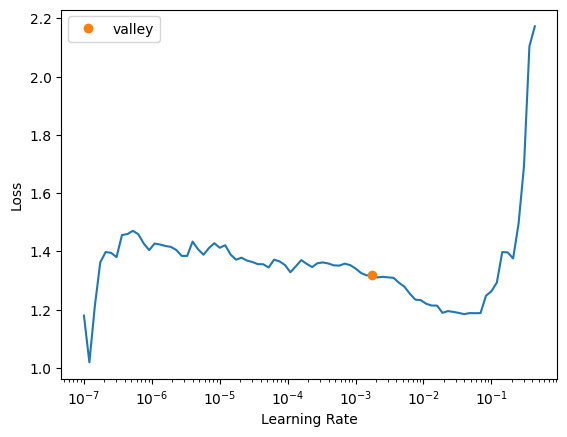

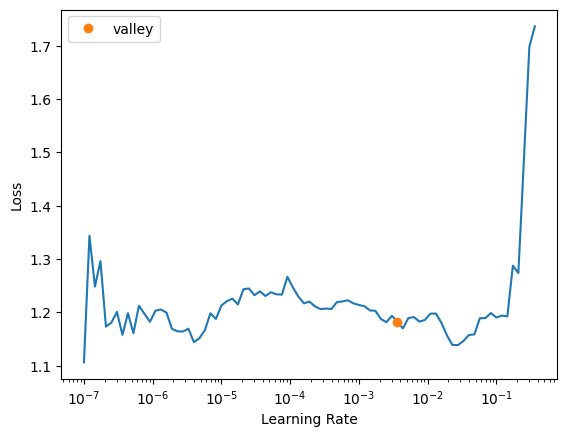

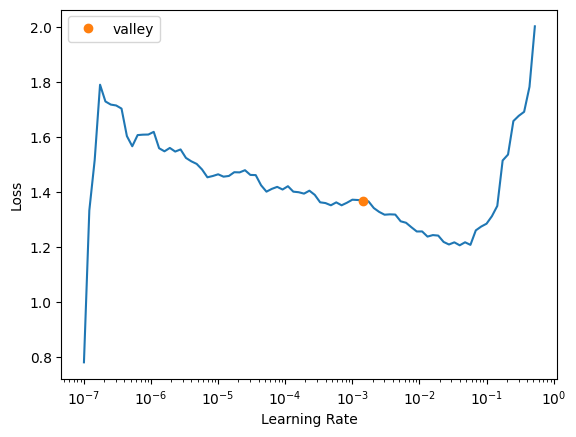

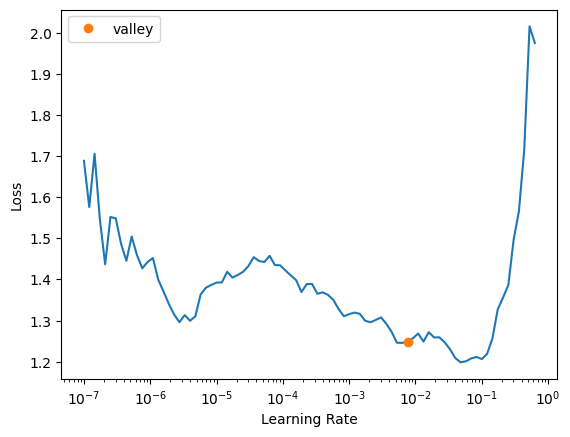

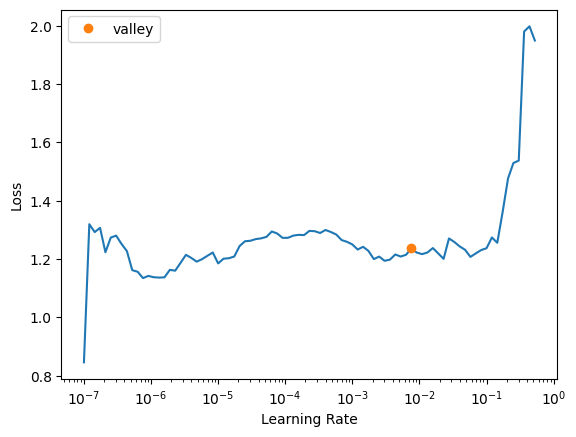

In [8]:
# %%
# 7. Model Training and Cross-Validation
all_fold_outputs = []
oof_preds = np.zeros((len(train_df), PipelineConfig.NUM_CLASSES))
model_folder = "/kaggle/working/"

for current_fold in range(PipelineConfig.N_SPLITS):
    print(f"Training on folds != {current_fold}, validating on fold {current_fold}")
    dls = get_dls(train_df, current_fold)
    learner = vision_learner(
        dls,
        PipelineConfig.MODEL_NAME,
        metrics=[accuracy, F1Score(average='binary')],
        loss_func=CrossEntropyLossFlat(),
        cbs=[SaveModelCallback(monitor='f1_score', comp=np.greater)],
        model_dir=model_folder    # <— here
    )
    lr_suggest = learner.lr_find(suggest_funcs=(valley, ))[0]
    learner.fine_tune(PipelineConfig.EPOCHS, lr_suggest)
    # Out-of-fold predictions
    val_idx = dls.valid.items.index
    preds, _ = learner.tta(dl=dls.valid, n=PipelineConfig.TTA_ROUNDS)
    oof_preds[val_idx] = preds.numpy()
    # Test predictions
    tst_dl = learner.dls.test_dl(test_df)
    t_preds, _ = learner.tta(dl=tst_dl, n=PipelineConfig.TTA_ROUNDS)
    all_fold_outputs.append(t_preds.numpy())
    # Cleanup
    del learner, dls
    gc.collect(); torch.cuda.empty_cache()

train_df['oof_probs'] = list(oof_preds)
train_df['pred_label'] = train_df['oof_probs'].apply(lambda x: int(x[1]>0.5))
print("Overall F1:", f1_score(train_df['label'], train_df['pred_label']))


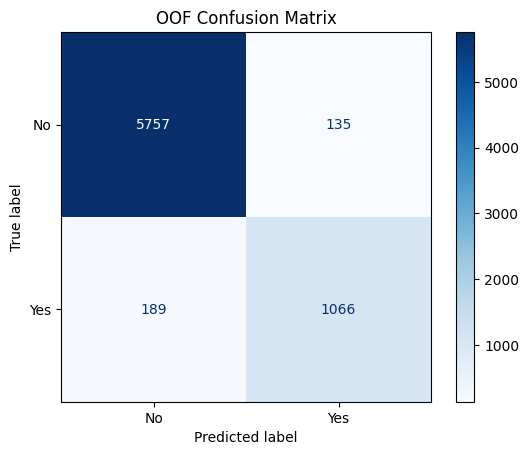

In [9]:
# %%
# 8. Confusion Matrix Visualization
cm = confusion_matrix(train_df['label'], train_df['pred_label'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')
plt.title('OOF Confusion Matrix')
plt.show()


In [10]:
# %%
# 9. Submission
stacked = np.stack(all_fold_outputs, axis=0).mean(axis=0)
test_df['label'] = np.argmax(stacked, axis=1)
submission = test_df[['ID','label']].rename(columns={'label':'target'})
output_csv = f"/kaggle/working/Baseline_{PipelineConfig.MODEL_NAME}_submission.csv"
submission.to_csv(output_csv, index=False)
print(f"Saved submission to {output_csv}")
# %%
# End of pipeline

Saved submission to /kaggle/working/Baseline_beitv2_large_patch16_224.in1k_ft_in22k_in1k_submission.csv
